In [333]:
import pandas as pd
import numpy as np
import re
import string

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

import nltk
from nltk.corpus import stopwords
nltk.download("stopwords")

stop_words = set(stopwords.words("english"))

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\kanna\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [334]:
claims = pd.read_csv("claims_pubhealth_sample.csv")
refs = pd.read_csv("reference_texts.csv")

print("Claims shape:", claims.shape)
print("Refs shape:", refs.shape)

display(claims.head())
display(refs.head())

Claims shape: (100, 1)
Refs shape: (4, 3)


,claim
0,A 14-year-old Texas girl became pregnant due t...
1,New Drug Spray May Help Premature Ejaculation
2,If we had been on 'Obamacare' and a bureaucrat...
3,People with Type-A blood are more susceptible ...
4,"""Judging by a recent vote, Rep. Debbie Wasserm..."


,id,source,text
0,1,NHS,Vitamin C supports the immune system but does ...
1,2,NHS,High protein intake may affect kidneys in rare...
2,3,WHO,There is no scientific evidence that detox tea...
3,4,NHS,Carrots contain vitamin A which supports eye h...


In [335]:
def clean_text(text):
    if pd.isna(text):
        return ""
    
    # lowercase
    text = text.lower()
    
    # remove punctuation
    text = text.translate(str.maketrans("", "", string.punctuation))
    
    # remove extra spaces
    text = re.sub(r"\s+", " ", text).strip()
    
    # remove stopwords
    words = text.split()
    words = [word for word in words if word not in stop_words]
    
    return " ".join(words)

In [336]:
claims["clean_claim"] = claims["claim"].apply(clean_text)
refs["clean_text"] = refs["text"].apply(clean_text)

display(claims[["claim", "clean_claim"]].head())
display(refs[["text", "clean_text"]].head())

,claim,clean_claim
0,A 14-year-old Texas girl became pregnant due t...,14yearold texas girl became pregnant due flu shot
1,New Drug Spray May Help Premature Ejaculation,new drug spray may help premature ejaculation
2,If we had been on 'Obamacare' and a bureaucrat...,obamacare bureaucrat trying tell could get cat...
3,People with Type-A blood are more susceptible ...,people typea blood susceptible covid19
4,"""Judging by a recent vote, Rep. Debbie Wasserm...",judging recent vote rep debbie wasserman schul...


,text,clean_text
0,Vitamin C supports the immune system but does ...,vitamin c supports immune system prevent colds
1,High protein intake may affect kidneys in rare...,high protein intake may affect kidneys rare co...
2,There is no scientific evidence that detox tea...,scientific evidence detox teas remove toxins
3,Carrots contain vitamin A which supports eye h...,carrots contain vitamin supports eye health


In [337]:
all_texts = list(claims["clean_claim"]) + list(refs["clean_text"])

vectorizer = TfidfVectorizer()
vectorizer.fit(all_texts)

claim_vectors = vectorizer.transform(claims["clean_claim"])
ref_vectors = vectorizer.transform(refs["clean_text"])

print("TF-IDF model built.")
print("Claim vectors shape:", claim_vectors.shape)
print("Reference vectors shape:", ref_vectors.shape)

TF-IDF model built.
Claim vectors shape: (100, 785)
Reference vectors shape: (4, 785)


In [338]:
results = []

for i, claim in enumerate(claims["claim"]):
    sim_scores = cosine_similarity(claim_vectors[i], ref_vectors)
    best_idx = np.argmax(sim_scores)

    results.append({
        "claim_id": i + 1,
        "claim": claims.loc[i, "claim"],
        "clean_claim": claims.loc[i, "clean_claim"],
        "best_reference_id": refs.loc[best_idx, "id"],
        "best_reference_source": refs.loc[best_idx, "source"],
        "best_reference_text": refs.loc[best_idx, "text"],
        "similarity_score": float(sim_scores[0][best_idx])
    })

results_tfidf = pd.DataFrame(results)
display(results_tfidf)

,claim_id,claim,clean_claim,best_reference_id,best_reference_source,best_reference_text,similarity_score
0,1,A 14-year-old Texas girl became pregnant due t...,14yearold texas girl became pregnant due flu shot,1,NHS,Vitamin C supports the immune system but does ...,0.000000
1,2,New Drug Spray May Help Premature Ejaculation,new drug spray may help premature ejaculation,2,NHS,High protein intake may affect kidneys in rare...,0.096219
2,3,If we had been on 'Obamacare' and a bureaucrat...,obamacare bureaucrat trying tell could get cat...,1,NHS,Vitamin C supports the immune system but does ...,0.000000
3,4,People with Type-A blood are more susceptible ...,people typea blood susceptible covid19,1,NHS,Vitamin C supports the immune system but does ...,0.000000
4,5,"""Judging by a recent vote, Rep. Debbie Wasserm...",judging recent vote rep debbie wasserman schul...,1,NHS,Vitamin C supports the immune system but does ...,0.000000
...,...,...,...,...,...,...,...
95,96,T-cell therapy results more modest than hoped ...,tcell therapy results modest hoped chronic leu...,1,NHS,Vitamin C supports the immune system but does ...,0.000000
96,97,U.S. to pay for thousands of doses of HIV drug...,us pay thousands doses hiv drugs venezuelan mi...,1,NHS,Vitamin C supports the immune system but does ...,0.000000
97,98,Prenatal Omega-3 Fatty Acid Supplements May Cu...,prenatal omega3 fatty acid supplements may cut...,1,NHS,Vitamin C supports the immune system but does ...,0.129497
98,99,"In 40 years of broadcast, I have never endorse...",40 years broadcast never endorsed candidate,1,NHS,Vitamin C supports the immune system but does ...,0.000000


In [339]:
results_tfidf.to_csv("tfidf_results_cleaned.csv", index=False)
print("Saved to tfidf_results_cleaned.csv")

Saved to tfidf_results_cleaned.csv


In [340]:
def assign_alignment(score):
    if score >= 0.60:
        return "consistent"
    elif score >= 0.35:
        return "partially aligned"
    else:
        return "inconsistent"

results_tfidf["alignment_label"] = results_tfidf["similarity_score"].apply(assign_alignment)

display(results_tfidf[["claim", "best_reference_text", "similarity_score", "alignment_label"]])

,claim,best_reference_text,similarity_score,alignment_label
0,A 14-year-old Texas girl became pregnant due t...,Vitamin C supports the immune system but does ...,0.000000,inconsistent
1,New Drug Spray May Help Premature Ejaculation,High protein intake may affect kidneys in rare...,0.096219,inconsistent
2,If we had been on 'Obamacare' and a bureaucrat...,Vitamin C supports the immune system but does ...,0.000000,inconsistent
3,People with Type-A blood are more susceptible ...,Vitamin C supports the immune system but does ...,0.000000,inconsistent
4,"""Judging by a recent vote, Rep. Debbie Wasserm...",Vitamin C supports the immune system but does ...,0.000000,inconsistent
...,...,...,...,...
95,T-cell therapy results more modest than hoped ...,Vitamin C supports the immune system but does ...,0.000000,inconsistent
96,U.S. to pay for thousands of doses of HIV drug...,Vitamin C supports the immune system but does ...,0.000000,inconsistent
97,Prenatal Omega-3 Fatty Acid Supplements May Cu...,Vitamin C supports the immune system but does ...,0.129497,inconsistent
98,"In 40 years of broadcast, I have never endorse...",Vitamin C supports the immune system but does ...,0.000000,inconsistent


In [341]:
def assign_alignment(score):
    if score >= 0.60:
        return "consistent"
    elif score >= 0.35:
        return "partially aligned"
    else:
        return "inconsistent"

results_tfidf["alignment_label"] = results_tfidf["similarity_score"].apply(assign_alignment)

display(results_tfidf[["claim", "best_reference_text", "similarity_score", "alignment_label"]])

,claim,best_reference_text,similarity_score,alignment_label
0,A 14-year-old Texas girl became pregnant due t...,Vitamin C supports the immune system but does ...,0.000000,inconsistent
1,New Drug Spray May Help Premature Ejaculation,High protein intake may affect kidneys in rare...,0.096219,inconsistent
2,If we had been on 'Obamacare' and a bureaucrat...,Vitamin C supports the immune system but does ...,0.000000,inconsistent
3,People with Type-A blood are more susceptible ...,Vitamin C supports the immune system but does ...,0.000000,inconsistent
4,"""Judging by a recent vote, Rep. Debbie Wasserm...",Vitamin C supports the immune system but does ...,0.000000,inconsistent
...,...,...,...,...
95,T-cell therapy results more modest than hoped ...,Vitamin C supports the immune system but does ...,0.000000,inconsistent
96,U.S. to pay for thousands of doses of HIV drug...,Vitamin C supports the immune system but does ...,0.000000,inconsistent
97,Prenatal Omega-3 Fatty Acid Supplements May Cu...,Vitamin C supports the immune system but does ...,0.129497,inconsistent
98,"In 40 years of broadcast, I have never endorse...",Vitamin C supports the immune system but does ...,0.000000,inconsistent


In [342]:
results_tfidf.to_csv("tfidf_results_with_labels.csv", index=False)
print("Saved to tfidf_results_with_labels.csv")

Saved to tfidf_results_with_labels.csv


In [343]:
from sentence_transformers import SentenceTransformer

In [344]:
model = SentenceTransformer("all-MiniLM-L6-v2")
print("Sentence-BERT model loaded.")

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Sentence-BERT model loaded.


In [345]:
claim_embeddings = model.encode(claims["clean_claim"].tolist(), convert_to_tensor=False)
ref_embeddings = model.encode(refs["clean_text"].tolist(), convert_to_tensor=False)

print("Embeddings created.")
print("Number of claim embeddings:", len(claim_embeddings))
print("Number of reference embeddings:", len(ref_embeddings))

Embeddings created.
Number of claim embeddings: 100
Number of reference embeddings: 4


In [346]:
claim_embeddings = model.encode(claims["clean_claim"].tolist(), convert_to_tensor=False)
ref_embeddings = model.encode(refs["clean_text"].tolist(), convert_to_tensor=False)

print("Embeddings created.")
print("Number of claim embeddings:", len(claim_embeddings))
print("Number of reference embeddings:", len(ref_embeddings))

Embeddings created.
Number of claim embeddings: 100
Number of reference embeddings: 4


In [347]:
from sklearn.metrics.pairwise import cosine_similarity

results_sbert = []

for i, claim in enumerate(claims["claim"]):
    sim_scores = cosine_similarity([claim_embeddings[i]], ref_embeddings)
    best_idx = np.argmax(sim_scores)

    results_sbert.append({
        "claim_id": i + 1,
        "claim": claims.loc[i, "claim"],
        "best_reference_id": refs.loc[best_idx, "id"],
        "best_reference_source": refs.loc[best_idx, "source"],
        "best_reference_text": refs.loc[best_idx, "text"],
        "similarity_score": float(sim_scores[0][best_idx])
    })

results_sbert = pd.DataFrame(results_sbert)
display(results_sbert)

,claim_id,claim,best_reference_id,best_reference_source,best_reference_text,similarity_score
0,1,A 14-year-old Texas girl became pregnant due t...,1,NHS,Vitamin C supports the immune system but does ...,0.137193
1,2,New Drug Spray May Help Premature Ejaculation,3,WHO,There is no scientific evidence that detox tea...,0.131855
2,3,If we had been on 'Obamacare' and a bureaucrat...,4,NHS,Carrots contain vitamin A which supports eye h...,0.103963
3,4,People with Type-A blood are more susceptible ...,1,NHS,Vitamin C supports the immune system but does ...,0.297110
4,5,"""Judging by a recent vote, Rep. Debbie Wasserm...",3,WHO,There is no scientific evidence that detox tea...,0.150461
...,...,...,...,...,...,...
95,96,T-cell therapy results more modest than hoped ...,1,NHS,Vitamin C supports the immune system but does ...,0.192479
96,97,U.S. to pay for thousands of doses of HIV drug...,3,WHO,There is no scientific evidence that detox tea...,0.043503
97,98,Prenatal Omega-3 Fatty Acid Supplements May Cu...,1,NHS,Vitamin C supports the immune system but does ...,0.526395
98,99,"In 40 years of broadcast, I have never endorse...",2,NHS,High protein intake may affect kidneys in rare...,0.049713


In [348]:
results_sbert["alignment_label"] = results_sbert["similarity_score"].apply(assign_alignment)

display(results_sbert[["claim", "best_reference_text", "similarity_score", "alignment_label"]])

,claim,best_reference_text,similarity_score,alignment_label
0,A 14-year-old Texas girl became pregnant due t...,Vitamin C supports the immune system but does ...,0.137193,inconsistent
1,New Drug Spray May Help Premature Ejaculation,There is no scientific evidence that detox tea...,0.131855,inconsistent
2,If we had been on 'Obamacare' and a bureaucrat...,Carrots contain vitamin A which supports eye h...,0.103963,inconsistent
3,People with Type-A blood are more susceptible ...,Vitamin C supports the immune system but does ...,0.297110,inconsistent
4,"""Judging by a recent vote, Rep. Debbie Wasserm...",There is no scientific evidence that detox tea...,0.150461,inconsistent
...,...,...,...,...
95,T-cell therapy results more modest than hoped ...,Vitamin C supports the immune system but does ...,0.192479,inconsistent
96,U.S. to pay for thousands of doses of HIV drug...,There is no scientific evidence that detox tea...,0.043503,inconsistent
97,Prenatal Omega-3 Fatty Acid Supplements May Cu...,Vitamin C supports the immune system but does ...,0.526395,partially aligned
98,"In 40 years of broadcast, I have never endorse...",High protein intake may affect kidneys in rare...,0.049713,inconsistent


In [349]:
results_sbert.to_csv("sbert_results_with_labels.csv", index=False)
print("Saved to sbert_results_with_labels.csv")

Saved to sbert_results_with_labels.csv


In [350]:
comparison = results_tfidf[["claim_id", "claim", "similarity_score", "alignment_label"]].copy()
comparison = comparison.rename(columns={
    "similarity_score": "tfidf_score",
    "alignment_label": "tfidf_label"
})

comparison["sbert_score"] = results_sbert["similarity_score"]
comparison["sbert_label"] = results_sbert["alignment_label"]

display(comparison)

,claim_id,claim,tfidf_score,tfidf_label,sbert_score,sbert_label
0,1,A 14-year-old Texas girl became pregnant due t...,0.000000,inconsistent,0.137193,inconsistent
1,2,New Drug Spray May Help Premature Ejaculation,0.096219,inconsistent,0.131855,inconsistent
2,3,If we had been on 'Obamacare' and a bureaucrat...,0.000000,inconsistent,0.103963,inconsistent
3,4,People with Type-A blood are more susceptible ...,0.000000,inconsistent,0.297110,inconsistent
4,5,"""Judging by a recent vote, Rep. Debbie Wasserm...",0.000000,inconsistent,0.150461,inconsistent
...,...,...,...,...,...,...
95,96,T-cell therapy results more modest than hoped ...,0.000000,inconsistent,0.192479,inconsistent
96,97,U.S. to pay for thousands of doses of HIV drug...,0.000000,inconsistent,0.043503,inconsistent
97,98,Prenatal Omega-3 Fatty Acid Supplements May Cu...,0.129497,inconsistent,0.526395,partially aligned
98,99,"In 40 years of broadcast, I have never endorse...",0.000000,inconsistent,0.049713,inconsistent


In [351]:
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np

# Load model
model = SentenceTransformer("all-MiniLM-L6-v2")

# Encode text
claim_embeddings = model.encode(claims["clean_claim"].tolist())
ref_embeddings = model.encode(refs["clean_text"].tolist())

# Compare
results_sbert = []

for i, claim in enumerate(claims["claim"]):
    sim_scores = cosine_similarity([claim_embeddings[i]], ref_embeddings)
    best_idx = np.argmax(sim_scores)

    results_sbert.append({
        "claim": claim,
        "best_reference": refs.loc[best_idx, "text"],
        "score": sim_scores[0][best_idx]
    })

results_sbert = pd.DataFrame(results_sbert)

print(results_sbert)

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


                                                claim  \
0   A 14-year-old Texas girl became pregnant due t...   
1       New Drug Spray May Help Premature Ejaculation   
2   If we had been on 'Obamacare' and a bureaucrat...   
3   People with Type-A blood are more susceptible ...   
4   "Judging by a recent vote, Rep. Debbie Wasserm...   
..                                                ...   
95  T-cell therapy results more modest than hoped ...   
96  U.S. to pay for thousands of doses of HIV drug...   
97  Prenatal Omega-3 Fatty Acid Supplements May Cu...   
98  In 40 years of broadcast, I have never endorse...   
99  Low-carb diet trumps low-fat on ‘good’ cholest...   

                                       best_reference     score  
0   Vitamin C supports the immune system but does ...  0.137193  
1   There is no scientific evidence that detox tea...  0.131855  
2   Carrots contain vitamin A which supports eye h...  0.103963  
3   Vitamin C supports the immune system but does .

In [352]:
import pandas as pd

train = pd.read_csv("train.tsv", sep="\t")
dev = pd.read_csv("dev.tsv", sep="\t")
test = pd.read_csv("test.tsv", sep="\t")

print("Train shape:", train.shape)
print("Dev shape:", dev.shape)
print("Test shape:", test.shape)

train.head()

Train shape: (9832, 9)
Dev shape: (1221, 9)
Test shape: (1235, 10)


,claim_id,claim,date_published,explanation,fact_checkers,main_text,sources,label,subjects
0,15661,"""The money the Clinton Foundation took from fr...","April 26, 2015","""Gingrich said the Clinton Foundation """"took m...",Katie Sanders,"""Hillary Clinton is in the political crosshair...",https://www.wsj.com/articles/clinton-foundatio...,false,"Foreign Policy, PunditFact, Newt Gingrich,"
1,9893,Annual Mammograms May Have More False-Positives,"October 18, 2011",This article reports on the results of a study...,,While the financial costs of screening mammogr...,,mixture,"Screening,WebMD,women's health"
2,11358,SBRT Offers Prostate Cancer Patients High Canc...,"September 28, 2016",This news release describes five-year outcomes...,"Mary Chris Jaklevic,Steven J. Atlas, MD, MPH,K...",The news release quotes lead researcher Robert...,https://www.healthnewsreview.org/wp-content/up...,mixture,"Association/Society news release,Cancer"
3,10166,"Study: Vaccine for Breast, Ovarian Cancer Has ...","November 8, 2011","While the story does many things well, the ove...",,"The story does discuss costs, but the framing ...",http://clinicaltrials.gov/ct2/results?term=can...,true,"Cancer,WebMD,women's health"
4,11276,Some appendicitis cases may not require ’emerg...,"September 20, 2010",We really don’t understand why only a handful ...,,"""Although the story didn’t cite the cost of ap...",,true,


In [353]:
claims_df = train[['claim']].dropna()

print(claims_df.head())
print("Total claims:", len(claims_df))

                                               claim
0  "The money the Clinton Foundation took from fr...
1    Annual Mammograms May Have More False-Positives
2  SBRT Offers Prostate Cancer Patients High Canc...
3  Study: Vaccine for Breast, Ovarian Cancer Has ...
4  Some appendicitis cases may not require ’emerg...
Total claims: 9824


In [354]:
claims_sample = claims_df.sample(100, random_state=42)

claims_sample.head()

,claim
6920,A 14-year-old Texas girl became pregnant due t...
9380,New Drug Spray May Help Premature Ejaculation
647,If we had been on 'Obamacare' and a bureaucrat...
1394,People with Type-A blood are more susceptible ...
360,"""Judging by a recent vote, Rep. Debbie Wasserm..."


In [355]:
claims_sample.to_csv("claims_pubhealth_sample.csv", index=False)

print("Saved successfully!")

Saved successfully!


In [356]:
import pandas as pd
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity

results = []

for i, claim in enumerate(claims["claim"]):
    sim_scores = cosine_similarity(claim_vectors[i], ref_vectors)
    best_idx = np.argmax(sim_scores)

    results.append({
        "claim_id": i + 1,
        "claim": claim,
        "best_reference_id": refs.loc[best_idx, "id"],
        "best_reference_source": refs.loc[best_idx, "source"],
        "best_reference_text": refs.loc[best_idx, "text"],
        "similarity_score": float(sim_scores[0][best_idx])
    })

results_df = pd.DataFrame(results)

print(results_df.head())
print(results_df.shape)

   claim_id                                              claim  \
0         1  A 14-year-old Texas girl became pregnant due t...   
1         2      New Drug Spray May Help Premature Ejaculation   
2         3  If we had been on 'Obamacare' and a bureaucrat...   
3         4  People with Type-A blood are more susceptible ...   
4         5  "Judging by a recent vote, Rep. Debbie Wasserm...   

   best_reference_id best_reference_source  \
0                  1                   NHS   
1                  2                   NHS   
2                  1                   NHS   
3                  1                   NHS   
4                  1                   NHS   

                                 best_reference_text  similarity_score  
0  Vitamin C supports the immune system but does ...          0.000000  
1  High protein intake may affect kidneys in rare...          0.096219  
2  Vitamin C supports the immune system but does ...          0.000000  
3  Vitamin C supports the immune s

In [357]:
print(type(claims))
print(type(refs))
print(claim_vectors.shape)
print(ref_vectors.shape)

<class 'pandas.core.frame.DataFrame'>
<class 'pandas.core.frame.DataFrame'>
(100, 785)
(4, 785)


In [358]:
print(results_df[["claim", "best_reference_text", "similarity_score"]].head(10))

                                               claim  \
0  A 14-year-old Texas girl became pregnant due t...   
1      New Drug Spray May Help Premature Ejaculation   
2  If we had been on 'Obamacare' and a bureaucrat...   
3  People with Type-A blood are more susceptible ...   
4  "Judging by a recent vote, Rep. Debbie Wasserm...   
5  Wisconsin glassblower customizes glassware for...   
6  Study: More omega-3 fats didn’t aid heart pati...   
7  “We’ve got to give the American public a rough...   
8  "Fulton County has successfully reduced the nu...   
9  During pregnancy, if the mother suffers organ ...   

                                 best_reference_text  similarity_score  
0  Vitamin C supports the immune system but does ...          0.000000  
1  High protein intake may affect kidneys in rare...          0.096219  
2  Vitamin C supports the immune system but does ...          0.000000  
3  Vitamin C supports the immune system but does ...          0.000000  
4  Vitamin C suppo

In [359]:
keywords = [
    "health", "diet", "vitamin", "protein", "weight",
    "fat", "exercise", "nutrition", "food", "disease",
    "heart", "diabetes", "blood", "medicine",
    "covid", "drug", "treatment", "therapy",
    "risk", "infection", "cancer", "doctor",
    "study", "patients", "clinical"
]

def is_health_claim(text):
    text = text.lower()

    # Strong condition: must contain at least one medical keyword
    keyword_match = any(word in text for word in keywords)

    # Additional filter: remove obvious non-health topics
    blacklist = ["election", "vote", "government", "obama", "county"]
    blacklist_match = any(word in text for word in blacklist)

    return keyword_match and not blacklist_match

In [360]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np
import pandas as pd

# Build TF-IDF on cleaned text
all_texts = list(claims["clean_claim"]) + list(refs["clean_text"])

vectorizer = TfidfVectorizer()
vectorizer.fit(all_texts)

claim_vectors = vectorizer.transform(claims["clean_claim"])
ref_vectors = vectorizer.transform(refs["clean_text"])

# Compare all claims with all references
results = []

for i, claim in enumerate(claims["claim"]):
    sim_scores = cosine_similarity(claim_vectors[i], ref_vectors)
    best_idx = np.argmax(sim_scores)

    results.append({
        "claim_id": i + 1,
        "claim": claim,
        "best_reference_id": refs.loc[best_idx, "id"],
        "best_reference_source": refs.loc[best_idx, "source"],
        "best_reference_text": refs.loc[best_idx, "text"],
        "similarity_score": float(sim_scores[0][best_idx])
    })

results_df = pd.DataFrame(results)

print(results_df[["claim", "best_reference_text", "similarity_score"]].head(10))

                                               claim  \
0  A 14-year-old Texas girl became pregnant due t...   
1      New Drug Spray May Help Premature Ejaculation   
2  If we had been on 'Obamacare' and a bureaucrat...   
3  People with Type-A blood are more susceptible ...   
4  "Judging by a recent vote, Rep. Debbie Wasserm...   
5  Wisconsin glassblower customizes glassware for...   
6  Study: More omega-3 fats didn’t aid heart pati...   
7  “We’ve got to give the American public a rough...   
8  "Fulton County has successfully reduced the nu...   
9  During pregnancy, if the mother suffers organ ...   

                                 best_reference_text  similarity_score  
0  Vitamin C supports the immune system but does ...          0.000000  
1  High protein intake may affect kidneys in rare...          0.096219  
2  Vitamin C supports the immune system but does ...          0.000000  
3  Vitamin C supports the immune system but does ...          0.000000  
4  Vitamin C suppo

In [361]:
filtered_claims = claims[claims["claim"].apply(is_health_claim)]

print("Before:", len(claims))
print("After:", len(filtered_claims))

claims = filtered_claims.reset_index(drop=True)
claims["id"] = claims.index + 1

Before: 100
After: 40


In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np
import pandas as pd

# Build TF-IDF on cleaned text
all_texts = list(claims["clean_claim"]) + list(refs["clean_text"])

vectorizer = TfidfVectorizer()
vectorizer.fit(all_texts)

claim_vectors = vectorizer.transform(claims["clean_claim"])
ref_vectors = vectorizer.transform(refs["clean_text"])

# Compare all claims with all references
results = []

for i, claim in enumerate(claims["claim"]):
    sim_scores = cosine_similarity(claim_vectors[i], ref_vectors)
    best_idx = np.argmax(sim_scores)

    results.append({
        "claim_id": claims.loc[i, "id"],
        "claim": claim,
        "best_reference_id": refs.loc[best_idx, "id"],
        "best_reference_source": refs.loc[best_idx, "source"],
        "best_reference_text": refs.loc[best_idx, "text"],
        "similarity_score": float(sim_scores[0][best_idx])
    })

results_df = pd.DataFrame(results)

print(results_df[["claim", "best_reference_text", "similarity_score"]].head(10))

                                               claim  \
0      New Drug Spray May Help Premature Ejaculation   
1  People with Type-A blood are more susceptible ...   
2  Study: More omega-3 fats didn’t aid heart pati...   
3  “I’ve gotten my life back”: Hopkins reports su...   
4  Study Shows Proposed Merck Drug For Diabetes L...   
5  H.R. 6666 provides $100 billion to entities th...   
6  The United States accounts for four percent of...   
7  CURE FOR CANCER? FDA ANNOUNCES NEW AGGRESSIVE ...   
8  In 2011 Mike Bloomberg said health care provid...   
9  Donald Trump Says 99% of COVID-19 cases “are t...   

                                 best_reference_text  similarity_score  
0  High protein intake may affect kidneys in rare...          0.106062  
1  Vitamin C supports the immune system but does ...          0.000000  
2  Vitamin C supports the immune system but does ...          0.000000  
3  Vitamin C supports the immune system but does ...          0.000000  
4  Vitamin C suppo

: 

In [1]:
import pandas as pd
import numpy as np
import re
import string
import nltk
from nltk.corpus import stopwords
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

# ----------------------------
# 1. Load datasets
# ----------------------------
claims = pd.read_csv("claims_pubhealth_sample.csv")
refs = pd.read_csv("reference_texts.csv")

# Add ID column to claims if missing
if "id" not in claims.columns:
    claims = claims.reset_index(drop=True)
    claims["id"] = claims.index + 1

print("Claims shape:", claims.shape)
print("References shape:", refs.shape)
print("\nClaims columns:", claims.columns.tolist())
print("References columns:", refs.columns.tolist())

# ----------------------------
# 2. Set up stopwords
# ----------------------------
nltk.download("stopwords")
stop_words = set(stopwords.words("english"))

# ----------------------------
# 3. Define cleaning function
# ----------------------------
def clean_text(text):
    if pd.isna(text):
        return ""
    text = str(text).lower()
    text = text.translate(str.maketrans("", "", string.punctuation))
    text = re.sub(r"\s+", " ", text).strip()
    words = text.split()
    words = [word for word in words if word not in stop_words]
    return " ".join(words)

# ----------------------------
# 4. Apply cleaning
# ----------------------------
claims["clean_claim"] = claims["claim"].apply(clean_text)
refs["clean_text"] = refs["text"].apply(clean_text)

print("\nSample cleaned claims:")
print(claims[["id", "claim", "clean_claim"]].head())

print("\nSample cleaned references:")
print(refs[["id", "source", "topic", "text", "clean_text"]].head())

# ----------------------------
# 5. Build TF-IDF vectors
# ----------------------------
all_texts = list(claims["clean_claim"]) + list(refs["clean_text"])

vectorizer = TfidfVectorizer()
vectorizer.fit(all_texts)

claim_vectors = vectorizer.transform(claims["clean_claim"])
ref_vectors = vectorizer.transform(refs["clean_text"])

print("\nTF-IDF vectorization complete.")
print("Claim vectors shape:", claim_vectors.shape)
print("Reference vectors shape:", ref_vectors.shape)

# ----------------------------
# 6. Compare each claim with all references
# ----------------------------
results = []

for i, claim in enumerate(claims["claim"]):
    sim_scores = cosine_similarity(claim_vectors[i], ref_vectors)
    best_idx = np.argmax(sim_scores)

    results.append({
        "claim_id": claims.loc[i, "id"],
        "claim": claims.loc[i, "claim"],
        "clean_claim": claims.loc[i, "clean_claim"],
        "best_reference_id": refs.loc[best_idx, "id"],
        "best_reference_source": refs.loc[best_idx, "source"],
        "best_reference_topic": refs.loc[best_idx, "topic"],
        "best_reference_text": refs.loc[best_idx, "text"],
        "similarity_score": float(sim_scores[0][best_idx])
    })

results_df = pd.DataFrame(results)

# ----------------------------
# 7. Add simple alignment labels
# ----------------------------
def assign_alignment(score):
    if score >= 0.60:
        return "consistent"
    elif score >= 0.35:
        return "partially aligned"
    else:
        return "inconsistent"

results_df["alignment_label"] = results_df["similarity_score"].apply(assign_alignment)

# ----------------------------
# 8. Show results
# ----------------------------
print("\nTop results preview:")
print(results_df[[
    "claim",
    "best_reference_source",
    "best_reference_topic",
    "similarity_score",
    "alignment_label"
]].head(15))

# ----------------------------
# 9. Save output
# ----------------------------
results_df.to_csv("tfidf_results_updated.csv", index=False)
print("\nSaved successfully as tfidf_results_updated.csv")

Claims shape: (100, 2)
References shape: (67, 5)

Claims columns: ['claim', 'id']
References columns: ['id', 'source', 'topic', 'text', 'url']

Sample cleaned claims:
   id                                              claim  \
0   1  A 14-year-old Texas girl became pregnant due t...   
1   2      New Drug Spray May Help Premature Ejaculation   
2   3  If we had been on 'Obamacare' and a bureaucrat...   
3   4  People with Type-A blood are more susceptible ...   
4   5  "Judging by a recent vote, Rep. Debbie Wasserm...   

                                         clean_claim  
0  14yearold texas girl became pregnant due flu shot  
1      new drug spray may help premature ejaculation  
2  obamacare bureaucrat trying tell could get cat...  
3             people typea blood susceptible covid19  
4  judging recent vote rep debbie wasserman schul...  

Sample cleaned references:
   id source      topic                                               text  \
0   1    NHS  vitamin c  Vitamin C, 

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\kanna\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [2]:
print(results_df[["claim", "best_reference_text", "similarity_score", "alignment_label"]].head(20))

                                                claim  \
0   A 14-year-old Texas girl became pregnant due t...   
1       New Drug Spray May Help Premature Ejaculation   
2   If we had been on 'Obamacare' and a bureaucrat...   
3   People with Type-A blood are more susceptible ...   
4   "Judging by a recent vote, Rep. Debbie Wasserm...   
5   Wisconsin glassblower customizes glassware for...   
6   Study: More omega-3 fats didn’t aid heart pati...   
7   “We’ve got to give the American public a rough...   
8   "Fulton County has successfully reduced the nu...   
9   During pregnancy, if the mother suffers organ ...   
10  “I’ve gotten my life back”: Hopkins reports su...   
11  Study Shows Proposed Merck Drug For Diabetes L...   
12  California Assembly OKs medical cannabis on K-...   
13  H.R. 6666 provides $100 billion to entities th...   
14  Up to half of all Americans have a pre-existin...   
15  The United States accounts for four percent of...   
16  No administration has accom

In [4]:
import pandas as pd
import numpy as np
import re
import string
import nltk
from nltk.corpus import stopwords
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

# ----------------------------
# 1. Load datasets
# ----------------------------
claims = pd.read_csv("claims_pubhealth_sample.csv")
refs = pd.read_csv("reference_texts.csv")

# Add ID column to claims if missing
if "id" not in claims.columns:
    claims = claims.reset_index(drop=True)
    claims["id"] = claims.index + 1

print("Original claims shape:", claims.shape)
print("References shape:", refs.shape)

# ----------------------------
# 2. Filter claims to keep more relevant health/medical ones
# ----------------------------
health_keywords = [
    "health", "diet", "vitamin", "protein", "weight", "fat", "exercise",
    "nutrition", "food", "disease", "heart", "diabetes", "blood",
    "medicine", "medical", "covid", "drug", "treatment", "therapy",
    "risk", "infection", "cancer", "doctor", "pregnancy", "patients",
    "hospital", "symptom", "symptoms", "cholesterol", "pressure"
]

blacklist_keywords = [
    "vote", "election", "county", "administration", "campaign",
    "congress", "senate", "government", "republican", "democrat"
]

def is_relevant_health_claim(text):
    text = str(text).lower()
    has_health = any(k in text for k in health_keywords)
    has_blacklist = any(k in text for k in blacklist_keywords)
    return has_health and not has_blacklist

filtered_claims = claims[claims["claim"].apply(is_relevant_health_claim)].copy()
filtered_claims = filtered_claims.reset_index(drop=True)
filtered_claims["id"] = filtered_claims.index + 1

print("Filtered claims shape:", filtered_claims.shape)

# IMPORTANT: replace claims with filtered claims
claims = filtered_claims

# ----------------------------
# 3. Set up stopwords
# ----------------------------
nltk.download("stopwords")
stop_words = set(stopwords.words("english"))

# ----------------------------
# 4. Cleaning function
# ----------------------------
def clean_text(text):
    if pd.isna(text):
        return ""
    text = str(text).lower()
    text = text.translate(str.maketrans("", "", string.punctuation))
    text = re.sub(r"\s+", " ", text).strip()
    words = text.split()
    words = [word for word in words if word not in stop_words]
    return " ".join(words)

# ----------------------------
# 5. Apply cleaning
# ----------------------------
claims["clean_claim"] = claims["claim"].apply(clean_text)
refs["clean_text"] = refs["text"].apply(clean_text)

print("\nSample cleaned claims:")
print(claims[["id", "claim", "clean_claim"]].head())

print("\nSample cleaned references:")
print(refs[["id", "source", "topic", "clean_text"]].head())

# ----------------------------
# 6. Build TF-IDF vectors
# ----------------------------
all_texts = list(claims["clean_claim"]) + list(refs["clean_text"])

vectorizer = TfidfVectorizer()
vectorizer.fit(all_texts)

claim_vectors = vectorizer.transform(claims["clean_claim"])
ref_vectors = vectorizer.transform(refs["clean_text"])

print("\nVector shapes:")
print("Claim vectors:", claim_vectors.shape)
print("Reference vectors:", ref_vectors.shape)

# ----------------------------
# 7. Compare each claim with all references
# ----------------------------
results = []

for i, claim in enumerate(claims["claim"]):
    sim_scores = cosine_similarity(claim_vectors[i], ref_vectors)
    best_idx = np.argmax(sim_scores)

    results.append({
        "claim_id": claims.loc[i, "id"],
        "claim": claims.loc[i, "claim"],
        "clean_claim": claims.loc[i, "clean_claim"],
        "best_reference_id": refs.loc[best_idx, "id"],
        "best_reference_source": refs.loc[best_idx, "source"],
        "best_reference_topic": refs.loc[best_idx, "topic"],
        "best_reference_text": refs.loc[best_idx, "text"],
        "similarity_score": float(sim_scores[0][best_idx])
    })

results_df = pd.DataFrame(results)

# ----------------------------
# 8. Add alignment labels
# ----------------------------
def assign_alignment(score):
    if score >= 0.60:
        return "consistent"
    elif score >= 0.35:
        return "partially aligned"
    else:
        return "inconsistent"

results_df["alignment_label"] = results_df["similarity_score"].apply(assign_alignment)

# ----------------------------
# 9. Show results
# ----------------------------
print("\nResults preview:")
print(results_df[[
    "claim",
    "best_reference_source",
    "best_reference_topic",
    "similarity_score",
    "alignment_label"
]].head(20))

print("\nSimilarity score summary:")
print(results_df["similarity_score"].describe())

# ----------------------------
# 10. Save results
# ----------------------------
results_df.to_csv("tfidf_results_updated.csv", index=False)
print("\nSaved successfully as tfidf_results_updated.csv")

Original claims shape: (100, 2)
References shape: (67, 5)
Filtered claims shape: (42, 2)

Sample cleaned claims:
   id                                              claim  \
0   1      New Drug Spray May Help Premature Ejaculation   
1   2  If we had been on 'Obamacare' and a bureaucrat...   
2   3  People with Type-A blood are more susceptible ...   
3   4  Study: More omega-3 fats didn’t aid heart pati...   
4   5  During pregnancy, if the mother suffers organ ...   

                                         clean_claim  
0      new drug spray may help premature ejaculation  
1  obamacare bureaucrat trying tell could get cat...  
2             people typea blood susceptible covid19  
3        study omega3 fats didn’t aid heart patients  
4  pregnancy mother suffers organ damage baby wom...  

Sample cleaned references:
   id source      topic                                         clean_text
0   1    NHS  vitamin c  vitamin c also known ascorbic acid helps prote...
1   2    NHS  vita

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\kanna\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


count    42.000000
mean      0.092906
std       0.054101
min       0.000000
25%       0.059103
50%       0.081741
75%       0.105721
max       0.264640
Name: similarity_score, dtype: float64

Saved successfully as tfidf_results_updated.csv


In [5]:
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np
import pandas as pd

# Load model
model = SentenceTransformer("all-MiniLM-L6-v2")

# Encode text
claim_embeddings = model.encode(claims["clean_claim"].tolist(), convert_to_tensor=False)
ref_embeddings = model.encode(refs["clean_text"].tolist(), convert_to_tensor=False)

results_sbert = []

for i, claim in enumerate(claims["claim"]):
    sim_scores = cosine_similarity([claim_embeddings[i]], ref_embeddings)
    best_idx = np.argmax(sim_scores)

    results_sbert.append({
        "claim_id": claims.loc[i, "id"],
        "claim": claims.loc[i, "claim"],
        "best_reference_id": refs.loc[best_idx, "id"],
        "best_reference_source": refs.loc[best_idx, "source"],
        "best_reference_topic": refs.loc[best_idx, "topic"],
        "best_reference_text": refs.loc[best_idx, "text"],
        "similarity_score": float(sim_scores[0][best_idx])
    })

results_sbert = pd.DataFrame(results_sbert)

print(results_sbert[[
    "claim",
    "best_reference_topic",
    "similarity_score"
]].head(20))

print("\nSBERT score summary:")
print(results_sbert["similarity_score"].describe())

# Save
results_sbert.to_csv("sbert_results_updated.csv", index=False)
print("\nSaved as sbert_results_updated.csv")

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


                                                claim   best_reference_topic  \
0       New Drug Spray May Help Premature Ejaculation          mental health   
1   If we had been on 'Obamacare' and a bureaucrat...         covid symptoms   
2   People with Type-A blood are more susceptible ...         covid symptoms   
3   Study: More omega-3 fats didn’t aid heart pati...            cholesterol   
4   During pregnancy, if the mother suffers organ ...           healthy diet   
5   “I’ve gotten my life back”: Hopkins reports su...  antibiotic resistance   
6   Study Shows Proposed Merck Drug For Diabetes L...               diabetes   
7   California Assembly OKs medical cannabis on K-...          mental health   
8   H.R. 6666 provides $100 billion to entities th...         covid symptoms   
9   The United States accounts for four percent of...         covid symptoms   
10  CURE FOR CANCER? FDA ANNOUNCES NEW AGGRESSIVE ...                 cancer   
11  In 2011 Mike Bloomberg said health c

Original claims shape: (100, 2)
References shape: (67, 5)

Reference source counts:
source
NHS    40
WHO    27
Name: count, dtype: int64

Filtered claims shape: (42, 2)

Sample cleaned claims:
   id                                              claim  \
0   1      New Drug Spray May Help Premature Ejaculation   
1   2  If we had been on 'Obamacare' and a bureaucrat...   
2   3  People with Type-A blood are more susceptible ...   
3   4  Study: More omega-3 fats didn’t aid heart pati...   
4   5  During pregnancy, if the mother suffers organ ...   

                                         clean_claim  
0      new drug spray may help premature ejaculation  
1  obamacare bureaucrat trying tell could get cat...  
2             people typea blood susceptible covid19  
3        study omega3 fats didn’t aid heart patients  
4  pregnancy mother suffers organ damage baby wom...  

Sample cleaned references:
   id source      topic                                         clean_text
0   1    NHS 

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\kanna\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.



SBERT results preview:
                                                claim   best_reference_topic  \
0       New Drug Spray May Help Premature Ejaculation          mental health   
1   If we had been on 'Obamacare' and a bureaucrat...         covid symptoms   
2   People with Type-A blood are more susceptible ...         covid symptoms   
3   Study: More omega-3 fats didn’t aid heart pati...            cholesterol   
4   During pregnancy, if the mother suffers organ ...           healthy diet   
5   “I’ve gotten my life back”: Hopkins reports su...  antibiotic resistance   
6   Study Shows Proposed Merck Drug For Diabetes L...               diabetes   
7   California Assembly OKs medical cannabis on K-...          mental health   
8   H.R. 6666 provides $100 billion to entities th...         covid symptoms   
9   The United States accounts for four percent of...         covid symptoms   
10  CURE FOR CANCER? FDA ANNOUNCES NEW AGGRESSIVE ...                 cancer   
11  In 2011 Mike

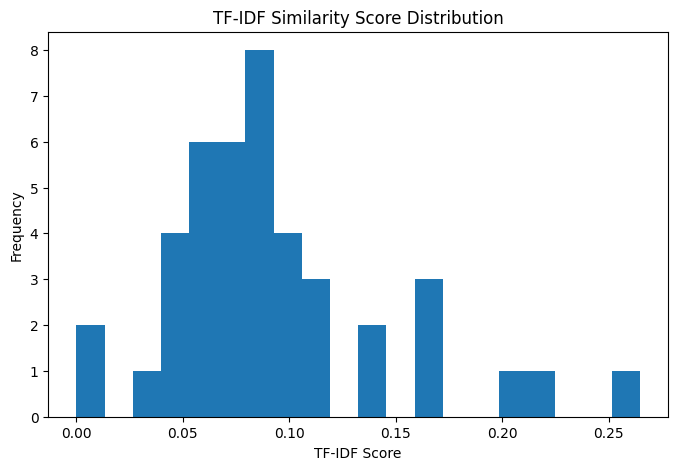

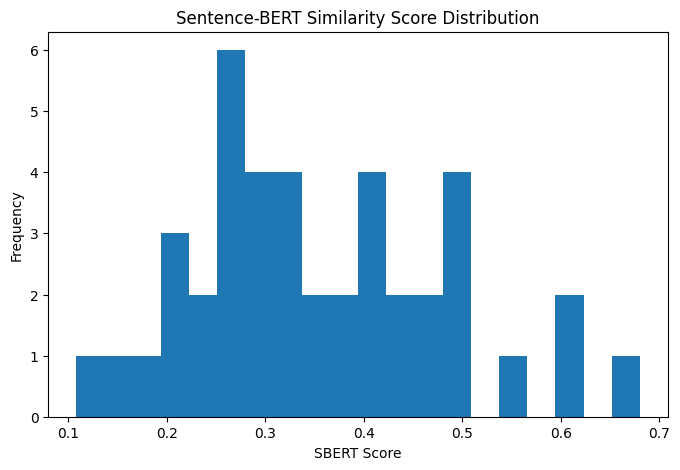

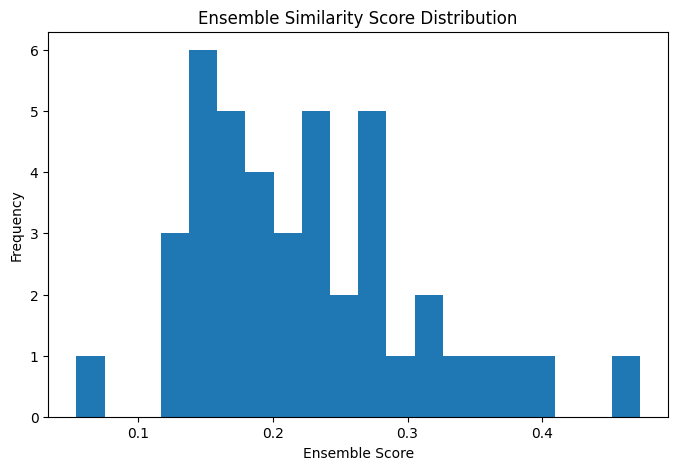


Saved files:
- tfidf_results_final.csv
- sbert_results_final.csv
- model_comparison_final.csv


In [8]:
import pandas as pd
import numpy as np
import re
import string
import nltk
import matplotlib.pyplot as plt

from nltk.corpus import stopwords
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sentence_transformers import SentenceTransformer

# =========================================================
# 1. LOAD DATA
# =========================================================
claims = pd.read_csv("claims_pubhealth_sample.csv")
refs = pd.read_csv("reference_texts.csv")

# Add ID column to claims if missing
if "id" not in claims.columns:
    claims = claims.reset_index(drop=True)
    claims["id"] = claims.index + 1

print("Original claims shape:", claims.shape)
print("References shape:", refs.shape)
print("\nReference source counts:")
print(refs["source"].value_counts())

# =========================================================
# 2. FILTER CLAIMS TO KEEP MORE RELEVANT HEALTH/MEDICAL ONES
# =========================================================
health_keywords = [
    "health", "diet", "vitamin", "protein", "weight", "fat", "exercise",
    "nutrition", "food", "disease", "heart", "diabetes", "blood",
    "medicine", "medical", "covid", "drug", "treatment", "therapy",
    "risk", "infection", "cancer", "doctor", "pregnancy", "patients",
    "hospital", "symptom", "symptoms", "cholesterol", "pressure",
    "mental", "antibiotic", "obesity", "smoking", "retinal", "ejaculation"
]

blacklist_keywords = [
    "vote", "election", "county", "administration", "campaign",
    "congress", "senate", "government", "republican", "democrat"
]

def is_relevant_health_claim(text):
    text = str(text).lower()
    has_health = any(k in text for k in health_keywords)
    has_blacklist = any(k in text for k in blacklist_keywords)
    return has_health and not has_blacklist

filtered_claims = claims[claims["claim"].apply(is_relevant_health_claim)].copy()
filtered_claims = filtered_claims.reset_index(drop=True)
filtered_claims["id"] = filtered_claims.index + 1

print("\nFiltered claims shape:", filtered_claims.shape)

# Replace claims with filtered version
claims = filtered_claims

# =========================================================
# 3. CLEAN TEXT
# =========================================================
nltk.download("stopwords")
stop_words = set(stopwords.words("english"))

def clean_text(text):
    if pd.isna(text):
        return ""
    text = str(text).lower()
    text = text.translate(str.maketrans("", "", string.punctuation))
    text = re.sub(r"\s+", " ", text).strip()
    words = text.split()
    words = [word for word in words if word not in stop_words]
    return " ".join(words)

claims["clean_claim"] = claims["claim"].apply(clean_text)
refs["clean_text"] = refs["text"].apply(clean_text)

print("\nSample cleaned claims:")
print(claims[["id", "claim", "clean_claim"]].head())

print("\nSample cleaned references:")
print(refs[["id", "source", "topic", "clean_text"]].head())

# =========================================================
# 4. TF-IDF MODEL
# =========================================================
all_texts = list(claims["clean_claim"]) + list(refs["clean_text"])

vectorizer = TfidfVectorizer()
vectorizer.fit(all_texts)

claim_vectors = vectorizer.transform(claims["clean_claim"])
ref_vectors = vectorizer.transform(refs["clean_text"])

results_tfidf = []

for i, claim in enumerate(claims["claim"]):
    sim_scores = cosine_similarity(claim_vectors[i], ref_vectors)
    best_idx = np.argmax(sim_scores)

    results_tfidf.append({
        "claim_id": claims.loc[i, "id"],
        "claim": claims.loc[i, "claim"],
        "clean_claim": claims.loc[i, "clean_claim"],
        "best_reference_id": refs.loc[best_idx, "id"],
        "best_reference_source": refs.loc[best_idx, "source"],
        "best_reference_topic": refs.loc[best_idx, "topic"],
        "best_reference_text": refs.loc[best_idx, "text"],
        "tfidf_score": float(sim_scores[0][best_idx])
    })

results_tfidf = pd.DataFrame(results_tfidf)

print("\nTF-IDF results preview:")
print(results_tfidf[[
    "claim",
    "best_reference_topic",
    "tfidf_score"
]].head(20))

print("\nTF-IDF score summary:")
print(results_tfidf["tfidf_score"].describe())

# =========================================================
# 5. TF-IDF ALIGNMENT LABELS
# =========================================================
def assign_alignment_tfidf(score):
    if score >= 0.20:
        return "consistent"
    elif score >= 0.08:
        return "partially aligned"
    else:
        return "inconsistent"

results_tfidf["tfidf_label"] = results_tfidf["tfidf_score"].apply(assign_alignment_tfidf)

# =========================================================
# 6. SENTENCE-BERT MODEL
# =========================================================
model = SentenceTransformer("all-MiniLM-L6-v2")

claim_embeddings = model.encode(claims["clean_claim"].tolist(), convert_to_tensor=False)
ref_embeddings = model.encode(refs["clean_text"].tolist(), convert_to_tensor=False)

results_sbert = []

for i, claim in enumerate(claims["claim"]):
    sim_scores = cosine_similarity([claim_embeddings[i]], ref_embeddings)
    best_idx = np.argmax(sim_scores)

    results_sbert.append({
        "claim_id": claims.loc[i, "id"],
        "claim": claims.loc[i, "claim"],
        "best_reference_id": refs.loc[best_idx, "id"],
        "best_reference_source": refs.loc[best_idx, "source"],
        "best_reference_topic": refs.loc[best_idx, "topic"],
        "best_reference_text": refs.loc[best_idx, "text"],
        "sbert_score": float(sim_scores[0][best_idx])
    })

results_sbert = pd.DataFrame(results_sbert)

print("\nSBERT results preview:")
print(results_sbert[[
    "claim",
    "best_reference_topic",
    "sbert_score"
]].head(20))

print("\nSBERT score summary:")
print(results_sbert["sbert_score"].describe())

# =========================================================
# 7. SBERT ALIGNMENT LABELS
# =========================================================
def assign_alignment_sbert(score):
    if score >= 0.50:
        return "consistent"
    elif score >= 0.30:
        return "partially aligned"
    else:
        return "inconsistent"

results_sbert["sbert_label"] = results_sbert["sbert_score"].apply(assign_alignment_sbert)

# =========================================================
# 8. MODEL COMPARISON TABLE
# =========================================================
comparison = results_tfidf[[
    "claim_id", "claim", "best_reference_topic", "tfidf_score", "tfidf_label"
]].copy()

comparison = comparison.rename(columns={
    "best_reference_topic": "tfidf_topic"
})

comparison["sbert_topic"] = results_sbert["best_reference_topic"]
comparison["sbert_score"] = results_sbert["sbert_score"]
comparison["sbert_label"] = results_sbert["sbert_label"]

print("\nModel comparison preview:")
print(comparison.head(20))

# =========================================================
# 9. SIMPLE ENSEMBLE LEARNING
# =========================================================
comparison["ensemble_score"] = (comparison["tfidf_score"] + comparison["sbert_score"]) / 2

def assign_alignment_ensemble(score):
    if score >= 0.32:
        return "consistent"
    elif score >= 0.18:
        return "partially aligned"
    else:
        return "inconsistent"

comparison["ensemble_label"] = comparison["ensemble_score"].apply(assign_alignment_ensemble)

print("\nEnsemble results preview:")
print(comparison[[
    "claim",
    "tfidf_score",
    "sbert_score",
    "ensemble_score",
    "ensemble_label"
]].head(20))

# =========================================================
# 10. SCORE DISTRIBUTION PLOTS (BELL CURVE IDEA)
# =========================================================
plt.figure(figsize=(8, 5))
plt.hist(results_tfidf["tfidf_score"], bins=20)
plt.title("TF-IDF Similarity Score Distribution")
plt.xlabel("TF-IDF Score")
plt.ylabel("Frequency")
plt.show()

plt.figure(figsize=(8, 5))
plt.hist(results_sbert["sbert_score"], bins=20)
plt.title("Sentence-BERT Similarity Score Distribution")
plt.xlabel("SBERT Score")
plt.ylabel("Frequency")
plt.show()

plt.figure(figsize=(8, 5))
plt.hist(comparison["ensemble_score"], bins=20)
plt.title("Ensemble Similarity Score Distribution")
plt.xlabel("Ensemble Score")
plt.ylabel("Frequency")
plt.show()

# =========================================================
# 11. SAVE ALL OUTPUTS
# =========================================================
results_tfidf.to_csv("tfidf_results_final.csv", index=False)
results_sbert.to_csv("sbert_results_final.csv", index=False)
comparison.to_csv("model_comparison_final.csv", index=False)

print("\nSaved files:")
print("- tfidf_results_final.csv")
print("- sbert_results_final.csv")
print("- model_comparison_final.csv")

In [9]:
print(comparison[[
    "claim",
    "tfidf_topic",
    "tfidf_score",
    "sbert_topic",
    "sbert_score",
    "ensemble_score",
    "ensemble_label"
]].head(20))

                                                claim  \
0       New Drug Spray May Help Premature Ejaculation   
1   If we had been on 'Obamacare' and a bureaucrat...   
2   People with Type-A blood are more susceptible ...   
3   Study: More omega-3 fats didn’t aid heart pati...   
4   During pregnancy, if the mother suffers organ ...   
5   “I’ve gotten my life back”: Hopkins reports su...   
6   Study Shows Proposed Merck Drug For Diabetes L...   
7   California Assembly OKs medical cannabis on K-...   
8   H.R. 6666 provides $100 billion to entities th...   
9   The United States accounts for four percent of...   
10  CURE FOR CANCER? FDA ANNOUNCES NEW AGGRESSIVE ...   
11  In 2011 Mike Bloomberg said health care provid...   
12  Donald Trump Says 99% of COVID-19 cases “are t...   
13  Have a baby at new low, low price, says fertil...   
14  Erbitux Cancer Drug Is Cleared For Use On Head...   
15  Swiss study suggests diabetes drugs double fra...   
16  Cognitive behavior therapy 

In [10]:
evaluation_sample = comparison.sample(15, random_state=1)

evaluation_sample = evaluation_sample[[
    "claim",
    "sbert_topic",
    "sbert_score",
    "ensemble_label"
]]

print(evaluation_sample)

                                                claim            sbert_topic  \
3   Study: More omega-3 fats didn’t aid heart pati...            cholesterol   
2   People with Type-A blood are more susceptible ...         covid symptoms   
23  McDonald's is giving free lunches to school-ag...         covid symptoms   
39  U.S. to pay for thousands of doses of HIV drug...  antibiotic resistance   
17  Region hit hard by opioids embraces jail-based...          mental health   
29  Congo police detain ex-health minister in Ebol...           covid advice   
19  GOOGLE RETINAL SCANS CAN PREDICT IF YOU WILL H...    diabetes prevention   
35  A fatal wave of molasses swept through Boston ...                smoking   
31  COVID-19 is “here to stay” and “we need to acc...         covid symptoms   
22  Anti-inflammatory diet could reduce risk of bo...           healthy diet   
21  In the health care bill, we're now offering in...  antibiotic resistance   
33  Child advocate sees lack of oversigh

In [11]:
sample = comparison.sample(15, random_state=42).copy()

sample = sample[[
    "claim",
    "tfidf_score",
    "sbert_score",
    "ensemble_score",
    "ensemble_label"
]]

# Add human column
sample["human_label"] = ""

print(sample)

                                                claim  tfidf_score  \
25  New study finds that proton therapy has fewer ...     0.224523   
13  Have a baby at new low, low price, says fertil...     0.103044   
8   H.R. 6666 provides $100 billion to entities th...     0.057258   
26  Only 15 percent of drug users are African-Amer...     0.043354   
4   During pregnancy, if the mother suffers organ ...     0.087494   
39  U.S. to pay for thousands of doses of HIV drug...     0.058124   
19  GOOGLE RETINAL SCANS CAN PREDICT IF YOU WILL H...     0.104620   
29  Congo police detain ex-health minister in Ebol...     0.000000   
30  Weight-Loss Surgery Better Than Diet and Exerc...     0.211531   
6   Study Shows Proposed Merck Drug For Diabetes L...     0.159684   
27  "Students have developed a nail polish called ...     0.048265   
12  Donald Trump Says 99% of COVID-19 cases “are t...     0.067456   
17  Region hit hard by opioids embraces jail-based...     0.068524   
9   The United State

In [13]:
import pandas as pd

evaluation = pd.read_csv("evaluation_sample.csv")

print(evaluation.head())
print(evaluation.columns)
print(evaluation.shape)

                                               claim  tfidf_score  \
0  New study finds that proton therapy has fewer ...     0.224523   
1  Have a baby at new low, low price, says fertil...     0.103044   
2  H.R. 6666 provides $100 billion to entities th...     0.057258   
3  Only 15 percent of drug users are African-Amer...     0.043354   
4  During pregnancy, if the mother suffers organ ...     0.087494   

   sbert_score  ensemble_score     ensemble_label         human_label  
0     0.394678        0.309601  partially aligned  partially alligned  
1     0.212955        0.158000       inconsistent        inconsistent  
2     0.474721        0.265990  partially aligned        inconsistent  
3     0.264609        0.153981       inconsistent        inconsistent  
4     0.254692        0.171093       inconsistent        inconsistent  
Index(['claim', 'tfidf_score', 'sbert_score', 'ensemble_score',
       'ensemble_label', 'human_label'],
      dtype='object')
(15, 6)


In [12]:
sample.to_csv("evaluation_sample.csv", index=False)

In [14]:
evaluation["human_label"] = evaluation["human_label"].replace({
    "not aligned": "inconsistent",
    "inconsistentt": "inconsistent",
    "partially aligned ": "partially aligned",
    " consistent": "consistent"
})

evaluation["ensemble_label"] = evaluation["ensemble_label"].replace({
    "not aligned": "inconsistent",
    "inconsistentt": "inconsistent"
})

print(evaluation[["ensemble_label", "human_label"]].head(15))

       ensemble_label         human_label
0   partially aligned  partially alligned
1        inconsistent        inconsistent
2   partially aligned        inconsistent
3        inconsistent        inconsistent
4        inconsistent        inconsistent
5        inconsistent        inconsistent
6   partially aligned  partially alligned
7        inconsistent        inconsistent
8          consistent          consistent
9          consistent          consistent
10       inconsistent        inconsistent
11  partially aligned  partially alligned
12       inconsistent        inconsistent
13  partially aligned  partially alligned
14  partially aligned  partially alligned


In [ ]:
accuracy = (evaluation["ensemble_label"] == evaluation["human_label"]).mean()
print("Accuracy:", round(accuracy, 4))

In [15]:
from sklearn.metrics import classification_report

y_true = evaluation["human_label"]
y_pred = evaluation["ensemble_label"]

print(classification_report(y_true, y_pred))

                    precision    recall  f1-score   support

        consistent       1.00      1.00      1.00         2
      inconsistent       1.00      0.88      0.93         8
 partially aligned       0.00      0.00      0.00         0
partially alligned       0.00      0.00      0.00         5

          accuracy                           0.60        15
         macro avg       0.50      0.47      0.48        15
      weighted avg       0.67      0.60      0.63        15



c:\Users\kanna\Desktop\Project\venv\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\kanna\Desktop\Project\venv\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\kanna\Desktop\Project\venv\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\

In [16]:
confusion = pd.crosstab(
    evaluation["human_label"],
    evaluation["ensemble_label"],
    rownames=["Human Label"],
    colnames=["Predicted Label"]
)

print(confusion)

Predicted Label     consistent  inconsistent  partially aligned
Human Label                                                    
consistent                   2             0                  0
inconsistent                 0             7                  1
partially alligned           0             0                  5


In [17]:
evaluation.to_csv("evaluation_checked.csv", index=False)
print("Saved as evaluation_checked.csv")

Saved as evaluation_checked.csv


In [18]:
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity

top_k_results = []

k_values = [1, 3, 5]

for i, claim in enumerate(claims["claim"]):
    sim_scores = cosine_similarity([claim_embeddings[i]], ref_embeddings)[0]
    ranked_idx = np.argsort(sim_scores)[::-1]  # highest to lowest

    row = {
        "claim_id": claims.loc[i, "id"],
        "claim": claim
    }

    for k in k_values:
        top_k_idx = ranked_idx[:k]
        top_k_topics = [refs.loc[idx, "topic"] for idx in top_k_idx]
        top_k_texts = [refs.loc[idx, "text"] for idx in top_k_idx]

        row[f"top_{k}_topics"] = " | ".join(top_k_topics)
        row[f"top_{k}_texts"] = " | ".join(top_k_texts)

    top_k_results.append(row)

top_k_df = pd.DataFrame(top_k_results)

print(top_k_df.head())
top_k_df.to_csv("top_k_candidates.csv", index=False)
print("Saved as top_k_candidates.csv")

   claim_id                                              claim  \
0         1      New Drug Spray May Help Premature Ejaculation   
1         2  If we had been on 'Obamacare' and a bureaucrat...   
2         3  People with Type-A blood are more susceptible ...   
3         4  Study: More omega-3 fats didn’t aid heart pati...   
4         5  During pregnancy, if the mother suffers organ ...   

     top_1_topics                                        top_1_texts  \
0   mental health  Alcohol affects the chemistry of the brain whi...   
1  covid symptoms  COVID-19 can affect people differently. Older ...   
2  covid symptoms  COVID-19 can affect people differently. Older ...   
3     cholesterol  A balanced diet should include unsaturated fat...   
4    healthy diet  Healthy dietary practices start early in life....   

                                        top_3_topics  \
0      mental health | mental health | mental health   
1  covid symptoms | antibiotic resistance | menta...   
2 

In [20]:
top_k_eval = pd.read_csv("top_k_candidates_labeled.csv")

print(top_k_eval.head())
print(top_k_eval.columns)

   claim_id                                              claim  \
0         1      New Drug Spray May Help Premature Ejaculation   
1         2  If we had been on 'Obamacare' and a bureaucrat...   
2         3  People with Type-A blood are more susceptible ...   
3         4  Study: More omega-3 fats didn’t aid heart pati...   
4         5  During pregnancy, if the mother suffers organ ...   

     top_1_topics                                        top_1_texts  \
0   mental health  Alcohol affects the chemistry of the brain whi...   
1  covid symptoms  COVID-19 can affect people differently. Older ...   
2  covid symptoms  COVID-19 can affect people differently. Older ...   
3     cholesterol  A balanced diet should include unsaturated fat...   
4    healthy diet  Healthy dietary practices start early in life....   

                                        top_3_topics  \
0      mental health | mental health | mental health   
1  covid symptoms | antibiotic resistance | menta...   
2 

In [21]:
def compute_precision_at_k(df, k):
    correct = 0

    for _, row in df.iterrows():
        gold = str(row["gold_topic"]).strip().lower()
        predicted_topics = str(row[f"top_{k}_topics"]).lower().split(" | ")

        if gold in predicted_topics:
            correct += 1

    return correct / len(df)

p1 = compute_precision_at_k(top_k_eval, 1)
p3 = compute_precision_at_k(top_k_eval, 3)
p5 = compute_precision_at_k(top_k_eval, 5)

print("Precision@1:", round(p1, 4))
print("Precision@3:", round(p3, 4))
print("Precision@5:", round(p5, 4))

Precision@1: 0.0238
Precision@3: 0.0476
Precision@5: 0.0714


In [23]:
def compute_precision_at_k(df, k):
    correct = 0

    for _, row in df.iterrows():
        gold = str(row["gold_topic"]).strip().lower()
        predicted_topics = str(row[f"top_{k}_topics"]).lower().split(" | ")

        if gold in predicted_topics:
            correct += 1

    return correct / len(df)

p1 = compute_precision_at_k(top_k_eval, 1)
p3 = compute_precision_at_k(top_k_eval, 3)
p5 = compute_precision_at_k(top_k_eval, 5)

print("Precision@1:", round(p1, 4))
print("Precision@3:", round(p3, 4))
print("Precision@5:", round(p5, 4))

Precision@1: 0.0238
Precision@3: 0.0476
Precision@5: 0.0714


In [24]:
def compute_precision_at_k(df, k):
    correct = 0

    for _, row in df.iterrows():
        gold = str(row["gold_topic"]).strip().lower()
        predicted_topics = str(row[f"top_{k}_topics"]).lower().split(" | ")

        if gold in predicted_topics:
            correct += 1

    return correct / len(df)

p1 = compute_precision_at_k(top_k_eval, 1)
p3 = compute_precision_at_k(top_k_eval, 3)
p5 = compute_precision_at_k(top_k_eval, 5)

print("Precision@1:", round(p1, 4))
print("Precision@3:", round(p3, 4))
print("Precision@5:", round(p5, 4))

Precision@1: 0.0238
Precision@3: 0.0476
Precision@5: 0.0714


In [26]:
import pandas as pd

# Create 40 sample from your comparison dataframe
sample = comparison.sample(40, random_state=42).copy()

# If reference text not present, attach it
if "best_reference_text" not in sample.columns:
    sample["best_reference_text"] = results_sbert["best_reference_text"].values[:len(sample)]

# Select required columns
sample = sample[[
    "claim",
    "best_reference_text",
    "tfidf_score",
    "sbert_score",
    "ensemble_score",
    "ensemble_label"
]]

# Add empty column for manual labels
sample["human_label"] = ""

# Save file
sample.to_csv("evaluation_sample_40.csv", index=False)

print("File created: evaluation_sample_40.csv")
print("👉 Now open this in Excel and fill 'human_label'")
print("Allowed labels: consistent / partially aligned / inconsistent")

File created: evaluation_sample_40.csv
👉 Now open this in Excel and fill 'human_label'
Allowed labels: consistent / partially aligned / inconsistent


In [32]:
import pandas as pd
from sklearn.metrics import classification_report

# Load labelled file
evaluation = pd.read_csv("evaluation_sample_40.csv")

# Clean labels (important)
evaluation["human_label"] = evaluation["human_label"].astype(str).str.strip().str.lower().replace({
    "not aligned": "inconsistent",
    "inconsistentt": "inconsistent",
    "partially alligned": "partially aligned",
    "partial aligned": "partially aligned",
    "consistent ": "consistent"
})

evaluation["ensemble_label"] = evaluation["ensemble_label"].astype(str).str.strip().str.lower().replace({
    "not aligned": "inconsistent",
    "inconsistentt": "inconsistent",
    "partially alligned": "partially aligned"
})

# Apply threshold logic (you can tweak values)
def assign_label(score):
    if score >= 0.40:
        return "consistent"
    elif score >= 0.22:
        return "partially aligned"
    else:
        return "inconsistent"

evaluation["new_label"] = evaluation["ensemble_score"].apply(assign_label)

# Confusion Matrix
conf_matrix = pd.crosstab(
    evaluation["human_label"],
    evaluation["new_label"],
    rownames=["Human Label"],
    colnames=["Predicted Label"]
)

print("\nConfusion Matrix:")
print(conf_matrix)

# Classification Report
print("\nClassification Report:")
print(classification_report(
    evaluation["human_label"],
    evaluation["new_label"],
    digits=3
))

# Accuracy
accuracy = (evaluation["human_label"] == evaluation["new_label"]).mean()
print("\nAccuracy:", round(accuracy, 3))

# Save final evaluated file
evaluation.to_csv("evaluation_checked_40.csv", index=False)

print("\nSaved: evaluation_checked_40.csv")


Confusion Matrix:
Predicted Label    consistent  inconsistent  partially aligned
Human Label                                                   
consistent                  1             0                  1
inconsistent                1            16                  9
partially aligned           0             5                  7

Classification Report:
                   precision    recall  f1-score   support

       consistent      0.500     0.500     0.500         2
     inconsistent      0.762     0.615     0.681        26
partially aligned      0.412     0.583     0.483        12

         accuracy                          0.600        40
        macro avg      0.558     0.566     0.555        40
     weighted avg      0.644     0.600     0.612        40


Accuracy: 0.6

Saved: evaluation_checked_40.csv


In [33]:
import numpy as np
from sklearn.metrics import f1_score

thresholds = np.arange(0.15, 0.5, 0.02)

results = []

for t1 in thresholds:
    for t2 in thresholds:
        if t2 <= t1:
            continue

        def assign_label(score):
            if score >= t2:
                return "consistent"
            elif score >= t1:
                return "partially aligned"
            else:
                return "inconsistent"

        preds = evaluation["ensemble_score"].apply(assign_label)

        f1 = f1_score(evaluation["human_label"], preds, average="macro")

        results.append((t1, t2, f1))

# sort best
results = sorted(results, key=lambda x: x[2], reverse=True)

print("Top 5 Thresholds:")
for r in results[:5]:
    print(f"Partial ≥ {r[0]:.2f}, Consistent ≥ {r[1]:.2f} → Macro F1 = {r[2]:.3f}")

Top 5 Thresholds:
Partial ≥ 0.25, Consistent ≥ 0.31 → Macro F1 = 0.606
Partial ≥ 0.27, Consistent ≥ 0.31 → Macro F1 = 0.590
Partial ≥ 0.25, Consistent ≥ 0.39 → Macro F1 = 0.590
Partial ≥ 0.23, Consistent ≥ 0.31 → Macro F1 = 0.587
Partial ≥ 0.27, Consistent ≥ 0.39 → Macro F1 = 0.577


In [36]:
# Create TF-IDF labels from tfidf_score
def assign_label_tfidf(score):
    if score >= 0.20:
        return "consistent"
    elif score >= 0.08:
        return "partially aligned"
    else:
        return "inconsistent"

# Create SBERT labels from sbert_score
def assign_label_sbert(score):
    if score >= 0.50:
        return "consistent"
    elif score >= 0.30:
        return "partially aligned"
    else:
        return "inconsistent"

# Create ensemble labels from ensemble_score
def assign_label_ensemble(score):
    if score >= 0.40:
        return "consistent"
    elif score >= 0.22:
        return "partially aligned"
    else:
        return "inconsistent"

evaluation["tfidf_label"] = evaluation["tfidf_score"].apply(assign_label_tfidf)
evaluation["sbert_label"] = evaluation["sbert_score"].apply(assign_label_sbert)
evaluation["ensemble_label_new"] = evaluation["ensemble_score"].apply(assign_label_ensemble)

In [37]:
print("TF-IDF ONLY")
print(classification_report(evaluation["human_label"], evaluation["tfidf_label"]))

print("SBERT ONLY")
print(classification_report(evaluation["human_label"], evaluation["sbert_label"]))

print("ENSEMBLE")
print(classification_report(evaluation["human_label"], evaluation["new_label"]))

TF-IDF ONLY
                   precision    recall  f1-score   support

       consistent       0.33      0.50      0.40         2
     inconsistent       0.78      0.54      0.64        26
partially aligned       0.37      0.58      0.45        12

         accuracy                           0.55        40
        macro avg       0.49      0.54      0.50        40
     weighted avg       0.63      0.55      0.57        40

SBERT ONLY
                   precision    recall  f1-score   support

       consistent       0.25      0.50      0.33         2
     inconsistent       0.75      0.46      0.57        26
partially aligned       0.35      0.58      0.44        12

         accuracy                           0.50        40
        macro avg       0.45      0.51      0.45        40
     weighted avg       0.60      0.50      0.52        40

ENSEMBLE
                   precision    recall  f1-score   support

       consistent       0.50      0.50      0.50         2
     inconsistent

In [38]:
high_sbert = evaluation[evaluation["sbert_score"] >= 0.45]

print(high_sbert[[
    "claim",
    "best_reference_text",
    "sbert_score"
]].head(20))

                                                claim  \
2   H.R. 6666 provides $100 billion to entities th...   
8   Weight-Loss Surgery Better Than Diet and Exerc...   
9   Study Shows Proposed Merck Drug For Diabetes L...   
11  Donald Trump Says 99% of COVID-19 cases “are t...   
14  Swiss study suggests diabetes drugs double fra...   
25  COVID-19 is “here to stay” and “we need to acc...   
27  People with Type-A blood are more susceptible ...   
29  Low-carb diet trumps low-fat on ‘good’ cholest...   
30  Study: More omega-3 fats didn’t aid heart pati...   
35  Anti-inflammatory diet could reduce risk of bo...   

                                  best_reference_text  sbert_score  
2   COVID-19 can affect people differently. Older ...     0.474721  
8   COVID-19 can affect people differently. Older ...     0.598065  
9   COVID-19 can affect people differently. Older ...     0.495700  
11  AMR makes infections harder to treat and makes...     0.487773  
14  Alcohol is classified a

In [39]:
candidate_eval = comparison.copy()

# bring in reference text and source from SBERT results
candidate_eval["best_reference_text"] = results_sbert["best_reference_text"].values
candidate_eval["best_reference_source"] = results_sbert["best_reference_source"].values

candidate_eval = candidate_eval[[
    "claim",
    "best_reference_text",
    "best_reference_source",
    "tfidf_score",
    "sbert_score",
    "ensemble_score"
]]

candidate_eval.to_csv("candidate_evaluation_pool.csv", index=False)
print("Saved candidate_evaluation_pool.csv")

Saved candidate_evaluation_pool.csv


In [46]:
import pandas as pd
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.metrics import classification_report, f1_score
from sentence_transformers import SentenceTransformer, util

# =========================================================
# 1. LOAD FILES
# =========================================================
evaluation = pd.read_csv("evaluation_balanced_45.csv")
refs = pd.read_csv("reference_texts.csv")

print("Evaluation shape:", evaluation.shape)
print("Reference shape:", refs.shape)

# =========================================================
# 2. PREPARE TEXT
# =========================================================
claims = evaluation["claim"].astype(str).tolist()
references = refs["text"].astype(str).tolist()

# =========================================================
# 3. TF-IDF SCORING
# =========================================================
vectorizer = TfidfVectorizer()
tfidf_matrix = vectorizer.fit_transform(claims + references)

claim_vecs = tfidf_matrix[:len(claims)]
ref_vecs = tfidf_matrix[len(claims):]

tfidf_scores = []
tfidf_best_text = []
tfidf_best_source = []

for i in range(len(claims)):
    sims = cosine_similarity(claim_vecs[i], ref_vecs)[0]
    best_idx = np.argmax(sims)

    tfidf_scores.append(float(sims[best_idx]))
    tfidf_best_text.append(refs.loc[best_idx, "text"])
    tfidf_best_source.append(refs.loc[best_idx, "source"] if "source" in refs.columns else "")

# =========================================================
# 4. SBERT SCORING
# =========================================================
model = SentenceTransformer("all-MiniLM-L6-v2")

claim_emb = model.encode(claims, convert_to_tensor=True)
ref_emb = model.encode(references, convert_to_tensor=True)

sbert_scores = []
sbert_best_text = []
sbert_best_source = []

for i in range(len(claims)):
    sims = util.cos_sim(claim_emb[i], ref_emb)[0].cpu().numpy()
    best_idx = np.argmax(sims)

    sbert_scores.append(float(sims[best_idx]))
    sbert_best_text.append(refs.loc[best_idx, "text"])
    sbert_best_source.append(refs.loc[best_idx, "source"] if "source" in refs.columns else "")

# =========================================================
# 5. ENSEMBLE SCORE
# =========================================================
ensemble_scores = [(t + s) / 2 for t, s in zip(tfidf_scores, sbert_scores)]

# Save scores into dataframe
evaluation["tfidf_score"] = tfidf_scores
evaluation["sbert_score"] = sbert_scores
evaluation["ensemble_score"] = ensemble_scores

# Keep SBERT best match as the main matched reference
evaluation["best_reference_text"] = sbert_best_text
evaluation["best_reference_source"] = sbert_best_source

# =========================================================
# 6. CLEAN HUMAN LABELS
# =========================================================
evaluation["human_label"] = evaluation["human_label"].astype(str).str.strip().str.lower().replace({
    "partially alligned": "partially aligned",
    "partial aligned": "partially aligned",
    "not aligned": "inconsistent",
    "inconsistentt": "inconsistent",
    "consistent ": "consistent",
    "inconsistent ": "inconsistent"
})

# =========================================================
# 7. THRESHOLD SWEEP FOR ENSEMBLE
#    Goal: maximize macro F1
# =========================================================
def assign_label(score, partial_thr, consistent_thr):
    if score >= consistent_thr:
        return "consistent"
    elif score >= partial_thr:
        return "partially aligned"
    else:
        return "inconsistent"

results = []

for partial_thr in np.arange(0.15, 0.36, 0.01):
    for consistent_thr in np.arange(0.30, 0.56, 0.01):
        if consistent_thr <= partial_thr:
            continue

        preds = evaluation["ensemble_score"].apply(
            lambda s: assign_label(s, partial_thr, consistent_thr)
        )

        macro_f1 = f1_score(
            evaluation["human_label"],
            preds,
            average="macro"
        )

        results.append({
            "partial_threshold": round(partial_thr, 2),
            "consistent_threshold": round(consistent_thr, 2),
            "macro_f1": macro_f1
        })

sweep_df = pd.DataFrame(results).sort_values("macro_f1", ascending=False)

print("\nTop 10 threshold combinations:")
print(sweep_df.head(10))

best_partial = float(sweep_df.iloc[0]["partial_threshold"])
best_consistent = float(sweep_df.iloc[0]["consistent_threshold"])

print("\nBest thresholds found:")
print("Partially aligned >= ", best_partial)
print("Consistent >= ", best_consistent)

# Final ensemble prediction using best thresholds
evaluation["ensemble_pred"] = evaluation["ensemble_score"].apply(
    lambda s: assign_label(s, best_partial, best_consistent)
)

# =========================================================
# 8. TF-IDF / SBERT LABELS FOR COMPARISON
# =========================================================
def assign_label_tfidf(score):
    if score >= 0.20:
        return "consistent"
    elif score >= 0.08:
        return "partially aligned"
    else:
        return "inconsistent"

def assign_label_sbert(score):
    if score >= 0.50:
        return "consistent"
    elif score >= 0.30:
        return "partially aligned"
    else:
        return "inconsistent"

evaluation["tfidf_pred"] = evaluation["tfidf_score"].apply(assign_label_tfidf)
evaluation["sbert_pred"] = evaluation["sbert_score"].apply(assign_label_sbert)

# =========================================================
# 9. ENSEMBLE EVALUATION
# =========================================================
print("\n================ ENSEMBLE CONFUSION MATRIX ================")
conf_matrix = pd.crosstab(
    evaluation["human_label"],
    evaluation["ensemble_pred"],
    rownames=["Human Label"],
    colnames=["Predicted Label"]
)
print(conf_matrix)

print("\n================ ENSEMBLE CLASSIFICATION REPORT ================")
print(classification_report(
    evaluation["human_label"],
    evaluation["ensemble_pred"],
    digits=3
))

# =========================================================
# 10. MODEL COMPARISON
# =========================================================
print("\n================ TF-IDF ONLY ================")
print(classification_report(
    evaluation["human_label"],
    evaluation["tfidf_pred"],
    digits=3
))

print("\n================ SBERT ONLY ================")
print(classification_report(
    evaluation["human_label"],
    evaluation["sbert_pred"],
    digits=3
))

print("\n================ ENSEMBLE ================")
print(classification_report(
    evaluation["human_label"],
    evaluation["ensemble_pred"],
    digits=3
))

# =========================================================
# 11. MISCLASSIFIED EXAMPLES (for error analysis)
# =========================================================
errors = evaluation[evaluation["human_label"] != evaluation["ensemble_pred"]].copy()

print("\n================ MISCLASSIFIED EXAMPLES ================")
print(errors[[
    "claim",
    "best_reference_text",
    "ensemble_score",
    "human_label",
    "ensemble_pred",
    "notes"
]].head(8))

# =========================================================
# 12. SAVE OUTPUT FILES
# =========================================================
evaluation.to_csv("evaluation_balanced_45_scored.csv", index=False)
sweep_df.to_csv("threshold_sweep_results.csv", index=False)
errors.to_csv("misclassified_examples.csv", index=False)

print("\nSaved files:")
print("- evaluation_balanced_45_scored.csv")
print("- threshold_sweep_results.csv")
print("- misclassified_examples.csv")

Evaluation shape: (45, 7)
Reference shape: (67, 5)


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.



Top 10 threshold combinations:
     partial_threshold  consistent_threshold  macro_f1
511               0.34                  0.43  0.778676
532               0.35                  0.43  0.777778
515               0.34                  0.47  0.776584
514               0.34                  0.46  0.776584
536               0.35                  0.47  0.776367
535               0.35                  0.46  0.776367
537               0.35                  0.48  0.773298
516               0.34                  0.48  0.772965
540               0.35                  0.51  0.769384
541               0.35                  0.52  0.769384

Best thresholds found:
Partially aligned >=  0.34
Consistent >=  0.43

================ ENSEMBLE CONFUSION MATRIX ================
Predicted Label    consistent  inconsistent  partially aligned
Human Label                                                   
consistent                 11             4                  0
inconsistent                1            1

In [51]:
import pandas as pd
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.metrics import classification_report, f1_score
from sentence_transformers import SentenceTransformer, util

# =========================================================
# 1) LOAD FILES
# =========================================================
evaluation = pd.read_csv("evaluation_balanced_45.csv")
refs = pd.read_csv("reference_texts.csv")

print("Evaluation shape:", evaluation.shape)
print("Reference shape:", refs.shape)

# Basic checks
required_eval_cols = {"claim", "human_label", "notes"}
missing_eval = required_eval_cols - set(evaluation.columns)
if missing_eval:
    raise ValueError(f"Missing columns in evaluation_balanced_45.csv: {missing_eval}")

if "text" not in refs.columns:
    raise ValueError("reference_texts.csv must contain a 'text' column.")

# Optional source column
if "source" not in refs.columns:
    refs["source"] = ""

# =========================================================
# 2) PREPARE TEXT
# =========================================================
claims = evaluation["claim"].astype(str).tolist()
references = refs["text"].astype(str).tolist()

# =========================================================
# 3) TF-IDF SCORING
# =========================================================
vectorizer = TfidfVectorizer()
tfidf_matrix = vectorizer.fit_transform(claims + references)

claim_vecs = tfidf_matrix[:len(claims)]
ref_vecs = tfidf_matrix[len(claims):]

tfidf_scores = []
tfidf_best_text = []
tfidf_best_source = []

for i in range(len(claims)):
    sims = cosine_similarity(claim_vecs[i], ref_vecs)[0]
    best_idx = int(np.argmax(sims))

    tfidf_scores.append(float(sims[best_idx]))
    tfidf_best_text.append(refs.loc[best_idx, "text"])
    tfidf_best_source.append(refs.loc[best_idx, "source"])

# =========================================================
# 4) SBERT SCORING
# =========================================================
model = SentenceTransformer("all-MiniLM-L6-v2")

claim_emb = model.encode(claims, convert_to_tensor=True)
ref_emb = model.encode(references, convert_to_tensor=True)

sbert_scores = []
sbert_best_text = []
sbert_best_source = []

for i in range(len(claims)):
    sims = util.cos_sim(claim_emb[i], ref_emb)[0].cpu().numpy()
    best_idx = int(np.argmax(sims))

    sbert_scores.append(float(sims[best_idx]))
    sbert_best_text.append(refs.loc[best_idx, "text"])
    sbert_best_source.append(refs.loc[best_idx, "source"])

# =========================================================
# 5) ENSEMBLE SCORE
# =========================================================
ensemble_scores = [(t + s) / 2 for t, s in zip(tfidf_scores, sbert_scores)]

evaluation["tfidf_score"] = tfidf_scores
evaluation["sbert_score"] = sbert_scores
evaluation["ensemble_score"] = ensemble_scores

# Keep SBERT best match as main matched reference
evaluation["best_reference_text"] = sbert_best_text
evaluation["best_reference_source"] = sbert_best_source

# =========================================================
# 6) CLEAN HUMAN LABELS
# =========================================================
evaluation["human_label"] = (
    evaluation["human_label"]
    .astype(str)
    .str.strip()
    .str.lower()
    .replace({
        "partially alligned": "partially aligned",
        "partial aligned": "partially aligned",
        "not aligned": "inconsistent",
        "inconsistentt": "inconsistent",
        "consistent ": "consistent",
        "inconsistent ": "inconsistent",
    })
)

allowed_labels = {"consistent", "partially aligned", "inconsistent"}
bad_labels = set(evaluation["human_label"].unique()) - allowed_labels
if bad_labels:
    raise ValueError(f"Unexpected human labels found: {bad_labels}")

# =========================================================
# 7) THRESHOLD SWEEP FOR ENSEMBLE
#    Goal: maximize macro F1
# =========================================================
def assign_label(score: float, partial_thr: float, consistent_thr: float) -> str:
    if score >= consistent_thr:
        return "consistent"
    elif score >= partial_thr:
        return "partially aligned"
    else:
        return "inconsistent"

results = []

for partial_thr in np.arange(0.15, 0.36, 0.01):
    for consistent_thr in np.arange(0.30, 0.56, 0.01):
        if consistent_thr <= partial_thr:
            continue

        preds = evaluation["ensemble_score"].apply(
            lambda s: assign_label(s, partial_thr, consistent_thr)
        )

        macro_f1 = f1_score(
            evaluation["human_label"],
            preds,
            average="macro"
        )

        results.append({
            "partial_threshold": round(float(partial_thr), 2),
            "consistent_threshold": round(float(consistent_thr), 2),
            "macro_f1": float(macro_f1)
        })

sweep_df = pd.DataFrame(results).sort_values("macro_f1", ascending=False)

print("\nTop 10 threshold combinations:")
print(sweep_df.head(10).to_string(index=False))

best_partial = float(sweep_df.iloc[0]["partial_threshold"])
best_consistent = float(sweep_df.iloc[0]["consistent_threshold"])

print("\nBest thresholds found:")
print("Partially aligned >=", best_partial)
print("Consistent >=", best_consistent)

evaluation["ensemble_pred"] = evaluation["ensemble_score"].apply(
    lambda s: assign_label(s, best_partial, best_consistent)
)

# =========================================================
# 8) SINGLE-MODEL LABELS FOR COMPARISON
# =========================================================
def assign_label_tfidf(score: float) -> str:
    if score >= 0.20:
        return "consistent"
    elif score >= 0.08:
        return "partially aligned"
    else:
        return "inconsistent"

def assign_label_sbert(score: float) -> str:
    if score >= 0.50:
        return "consistent"
    elif score >= 0.30:
        return "partially aligned"
    else:
        return "inconsistent"

evaluation["tfidf_pred"] = evaluation["tfidf_score"].apply(assign_label_tfidf)
evaluation["sbert_pred"] = evaluation["sbert_score"].apply(assign_label_sbert)

# =========================================================
# 9) ENSEMBLE EVALUATION
# =========================================================
print("\n================ ENSEMBLE CONFUSION MATRIX ================")
conf_matrix = pd.crosstab(
    evaluation["human_label"],
    evaluation["ensemble_pred"],
    rownames=["Human Label"],
    colnames=["Predicted Label"]
)
print(conf_matrix.to_string())

print("\n================ ENSEMBLE CLASSIFICATION REPORT ================")
ensemble_report = classification_report(
    evaluation["human_label"],
    evaluation["ensemble_pred"],
    digits=3
)
print(ensemble_report)

# =========================================================
# 10) MODEL COMPARISON
# =========================================================
print("\n================ TF-IDF ONLY ================")
tfidf_report = classification_report(
    evaluation["human_label"],
    evaluation["tfidf_pred"],
    digits=3
)
print(tfidf_report)

print("\n================ SBERT ONLY ================")
sbert_report = classification_report(
    evaluation["human_label"],
    evaluation["sbert_pred"],
    digits=3
)
print(sbert_report)

print("\n================ ENSEMBLE ================")
print(ensemble_report)

# =========================================================
# 11) MISCLASSIFIED EXAMPLES (for error analysis)
# =========================================================
errors = evaluation[evaluation["human_label"] != evaluation["ensemble_pred"]].copy()

print("\n================ MISCLASSIFIED EXAMPLES ================")
cols_to_show = [
    "claim",
    "best_reference_text",
    "ensemble_score",
    "human_label",
    "ensemble_pred",
    "notes"
]
print(errors[cols_to_show].head(8).to_string(index=False))

# =========================================================
# 12) SAVE OUTPUT FILES
# =========================================================
evaluation.to_csv("evaluation_balanced_45_scored.csv", index=False)
sweep_df.to_csv("threshold_sweep_results.csv", index=False)
errors.to_csv("misclassified_examples.csv", index=False)

print("\nSaved files:")
print("- evaluation_balanced_45_scored.csv")
print("- threshold_sweep_results.csv")
print("- misclassified_examples.csv")

Evaluation shape: (45, 7)
Reference shape: (67, 5)


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.



Top 10 threshold combinations:
 partial_threshold  consistent_threshold  macro_f1
              0.34                  0.43  0.778676
              0.35                  0.43  0.777778
              0.34                  0.47  0.776584
              0.34                  0.46  0.776584
              0.35                  0.47  0.776367
              0.35                  0.46  0.776367
              0.35                  0.48  0.773298
              0.34                  0.48  0.772965
              0.35                  0.51  0.769384
              0.35                  0.52  0.769384

Best thresholds found:
Partially aligned >= 0.34
Consistent >= 0.43

================ ENSEMBLE CONFUSION MATRIX ================
Predicted Label    consistent  inconsistent  partially aligned
Human Label                                                   
consistent                 11             4                  0
inconsistent                1            13                  1
partially aligned        

In [50]:
import pandas as pd
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.metrics import classification_report
from sentence_transformers import SentenceTransformer, util

# =========================================================
# 1. LOAD TEST SET
# =========================================================
evaluation = pd.read_csv("evaluation_test_18.csv")
refs = pd.read_csv("reference_texts.csv")

claims = evaluation["claim"].astype(str).tolist()
references = refs["text"].astype(str).tolist()

# =========================================================
# 2. TF-IDF
# =========================================================
vectorizer = TfidfVectorizer()
tfidf_matrix = vectorizer.fit_transform(claims + references)

claim_vecs = tfidf_matrix[:len(claims)]
ref_vecs = tfidf_matrix[len(claims):]

tfidf_scores = []

for i in range(len(claims)):
    sims = cosine_similarity(claim_vecs[i], ref_vecs)[0]
    tfidf_scores.append(float(max(sims)))

# =========================================================
# 3. SBERT
# =========================================================
model = SentenceTransformer("all-MiniLM-L6-v2")

claim_emb = model.encode(claims, convert_to_tensor=True)
ref_emb = model.encode(references, convert_to_tensor=True)

sbert_scores = []

for i in range(len(claims)):
    sims = util.cos_sim(claim_emb[i], ref_emb)[0]
    sbert_scores.append(float(sims.max()))

# =========================================================
# 4. ENSEMBLE
# =========================================================
evaluation["tfidf_score"] = tfidf_scores
evaluation["sbert_score"] = sbert_scores
evaluation["ensemble_score"] = (evaluation["tfidf_score"] + evaluation["sbert_score"]) / 2

# =========================================================
# 5. FIXED THRESHOLDS (IMPORTANT)
# =========================================================
best_partial = 0.34
best_consistent = 0.43

def assign_label(score):
    if score >= best_consistent:
        return "consistent"
    elif score >= best_partial:
        return "partially aligned"
    else:
        return "inconsistent"

evaluation["ensemble_pred"] = evaluation["ensemble_score"].apply(assign_label)

# =========================================================
# 6. CLEAN LABELS
# =========================================================
evaluation["human_label"] = evaluation["human_label"].str.strip().str.lower()

# =========================================================
# 7. RESULTS
# =========================================================
print("\n=== CONFUSION MATRIX ===")
print(pd.crosstab(evaluation["human_label"], evaluation["ensemble_pred"]))

print("\n=== CLASSIFICATION REPORT ===")
print(classification_report(evaluation["human_label"], evaluation["ensemble_pred"], digits=3))

# =========================================================
# 8. MODEL COMPARISON (OPTIONAL)
# =========================================================
def tfidf_label(score):
    if score >= 0.20:
        return "consistent"
    elif score >= 0.08:
        return "partially aligned"
    else:
        return "inconsistent"

def sbert_label(score):
    if score >= 0.50:
        return "consistent"
    elif score >= 0.30:
        return "partially aligned"
    else:
        return "inconsistent"

evaluation["tfidf_pred"] = evaluation["tfidf_score"].apply(tfidf_label)
evaluation["sbert_pred"] = evaluation["sbert_score"].apply(sbert_label)

print("\n=== TF-IDF ===")
print(classification_report(evaluation["human_label"], evaluation["tfidf_pred"], digits=3))

print("\n=== SBERT ===")
print(classification_report(evaluation["human_label"], evaluation["sbert_pred"], digits=3))

print("\n=== ENSEMBLE ===")
print(classification_report(evaluation["human_label"], evaluation["ensemble_pred"], digits=3))

# =========================================================
# 9. MISCLASSIFIED
# =========================================================
errors = evaluation[evaluation["human_label"] != evaluation["ensemble_pred"]]

print("\n=== MISCLASSIFIED ===")
print(errors[["claim", "ensemble_score", "human_label", "ensemble_pred"]].head(8))

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.



=== CONFUSION MATRIX ===
ensemble_pred      consistent  inconsistent  partially aligned
human_label                                                   
consistent                  5             0                  1
inconsistent                0             4                  2
partially aligned           3             1                  2

=== CLASSIFICATION REPORT ===
                   precision    recall  f1-score   support

       consistent      0.625     0.833     0.714         6
     inconsistent      0.800     0.667     0.727         6
partially aligned      0.400     0.333     0.364         6

         accuracy                          0.611        18
        macro avg      0.608     0.611     0.602        18
     weighted avg      0.608     0.611     0.602        18


=== TF-IDF ===
                   precision    recall  f1-score   support

       consistent      0.556     0.833     0.667         6
     inconsistent      1.000     0.167     0.286         6
partially aligned 

c:\Users\kanna\Desktop\Project\venv\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\kanna\Desktop\Project\venv\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\kanna\Desktop\Project\venv\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape